In [1]:
import pyspark.sql.functions as f
import matplotlib.pyplot as plt
import pyspark.sql
from pyspark.sql.window import Window

In [2]:
global spark
spark = (
        pyspark.sql.SparkSession.builder
        .config('spark.driver.memory', '14g')
        .config('spark.executor.memory', '14g')
        .getOrCreate()
)
spark.version

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


24/01/18 15:41:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/01/18 15:41:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


'3.3.3'

In [3]:
pics_predictions = spark.read.parquet('gs://genetics_etl_python_playground/releases/24.01/locus_to_gene_predictions/')

In [4]:
print("Number of unique studyLocusIds with at least one L2G score >= 0.5:",
    (
    pics_predictions
    .filter(f.col("score") >= 0.5)
    .sort(f.col("studyLocusId"))
    .select("studyLocusId")
    .distinct()
    .count()
    )
)

Number of unique studyLocusIds with at least one L2G score >= 0.5: 290442


In [5]:
print("Number of unique studyLocusIds in total:",
    (
    pics_predictions
    .select("studyLocusId")
    .distinct()
    .count()
    )
)

Number of unique studyLocusIds in total: 545284


In [6]:
window = (
    Window.partitionBy("studyLocusId")
    .orderBy(f.col("score").desc(), f.monotonically_increasing_id())
)
pics_predictions_ranked = (
    pics_predictions
    .withColumn("rank", f.rank().over(window))
)
predictions_filtered = (
    pics_predictions_ranked
    .filter(f.col("rank") == 1)
    .drop("rank")
)

predictions_filtered.show()
predictions_filtered.count()

+--------------------+---------------+-------------------+
|        studyLocusId|         geneId|              score|
+--------------------+---------------+-------------------+
|-9222709359911414559|ENSG00000111300| 0.8649893403053284|
|-9222460823293153000|ENSG00000091732| 0.9426510334014893|
|-9222295961629847227|ENSG00000116786| 0.9409350156784058|
|-9222062268155066964|ENSG00000132872|0.04256463423371315|
|-9222018241250979266|ENSG00000135298| 0.9936550855636597|
|-9221785276875048820|ENSG00000182836|   0.98954176902771|
|-9221662644183536443|ENSG00000088538| 0.8196413516998291|
|-9221297798747179245|ENSG00000198563|0.47551366686820984|
|-9221295228845269211|ENSG00000069667|0.24267183244228363|
|-9221093176905172519|ENSG00000285077|0.04256463423371315|
|-9220786524400744944|ENSG00000105852|0.48622599244117737|
|-9220245091780638156|ENSG00000130173| 0.7475139498710632|
|-9220060276920732219|ENSG00000270264|0.25535696744918823|
|-9220029556283961804|ENSG00000049618| 0.193775743246078

545284

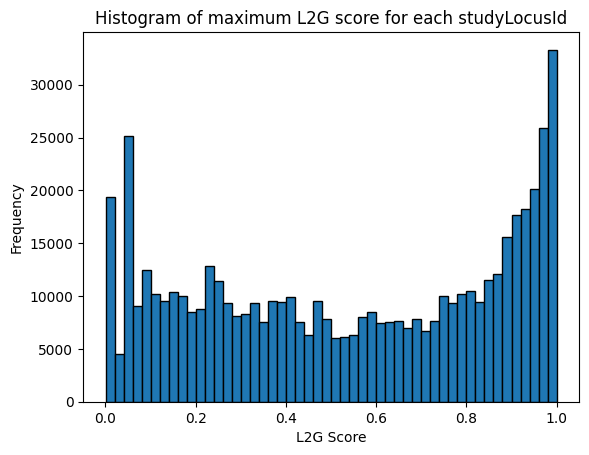

In [7]:
scores = predictions_filtered.toPandas()["score"]
plt.hist(scores, bins=50, edgecolor='black')
plt.xlabel("L2G Score")
plt.ylabel("Frequency")
plt.title("Histogram of maximum L2G score for each studyLocusId")
plt.show()

In [8]:
cred_sets = (
    spark.read.parquet("gs://genetics_etl_python_playground/releases/24.01/credible_set/finngen")
    .union(spark.read.parquet("gs://genetics_etl_python_playground/releases/24.01/credible_set/gwas_catalog_curated"))
    .union(spark.read.parquet("gs://genetics_etl_python_playground/releases/24.01/credible_set/gwas_catalog_summary_statistics"))
)
cred_sets.persist()
cred_sets.printSchema()
cred_sets.select("studyLocusId").distinct().count()

root
 |-- studyLocusId: long (nullable = true)
 |-- variantId: string (nullable = true)
 |-- chromosome: string (nullable = true)
 |-- position: integer (nullable = true)
 |-- studyId: string (nullable = true)
 |-- beta: double (nullable = true)
 |-- pValueMantissa: float (nullable = true)
 |-- pValueExponent: integer (nullable = true)
 |-- effectAlleleFrequencyFromSource: float (nullable = true)
 |-- standardError: double (nullable = true)
 |-- subStudyDescription: string (nullable = true)
 |-- qualityControls: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- finemappingMethod: string (nullable = true)
 |-- sampleSize: integer (nullable = true)
 |-- ldSet: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- tagVariantId: string (nullable = true)
 |    |    |-- r2Overall: double (nullable = true)
 |-- locus: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- variantId: string (nullable = 

711206

In [9]:
missing = (
    cred_sets
    .filter(f.size(f.col('ldSet')) == 0)
)

missing.show(10, False)
missing.count()

+--------------------+----------------+----------+---------+----------------------+----------+--------------+--------------+-------------------------------+-------------+-------------------+--------------------------------------------------------------+-----------------+----------+-----+-----+
|studyLocusId        |variantId       |chromosome|position |studyId               |beta      |pValueMantissa|pValueExponent|effectAlleleFrequencyFromSource|standardError|subStudyDescription|qualityControls                                               |finemappingMethod|sampleSize|ldSet|locus|
+--------------------+----------------+----------+---------+----------------------+----------+--------------+--------------+-------------------------------+-------------+-------------------+--------------------------------------------------------------+-----------------+----------+-----+-----+
|1471660588553562409 |10_72314803_C_G |10        |72314803 |FINNGEN_R10_HEIGHT_IRN|0.0171224 |1.053         |-8    

60421

In [10]:
unique_strings = (
    missing
    .select(f.explode(missing.qualityControls)).distinct()
)
unique_strings.show(20, False)

24/01/18 15:44:48 WARN MemoryStore: Not enough space to cache rdd_66_9 in memory! (computed 261.0 MiB so far)


+----------------------------------------------------------------+
|col                                                             |
+----------------------------------------------------------------+
|Explained by a more significant variant in high LD (clumped)    |
|Palindrome alleles - cannot harmonize                           |
|LD block does not contain variants at the required R^2 threshold|
|Subsignificant p-value                                          |
|Composite association                                           |
|Variant inconsistency                                           |
+----------------------------------------------------------------+



In [11]:
l2g_credset = (
    predictions_filtered
    .join(cred_sets,
          on="studyLocusId",
          how="inner")
)
l2g_credset.show(1, False, True)

-RECORD 0-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 studyL

In [12]:
l2g_credset_counted = (
    l2g_credset
    .withColumn("credCount95", f.size(f.filter(l2g_credset.locus, lambda x: x.is95CredibleSet)))
    .withColumn("credCount99", f.size(f.filter(l2g_credset.locus, lambda x : x.is99CredibleSet)))
    .withColumn("PIP_0_9", f.when(f.array_max(l2g_credset.locus.posteriorProbability) >= 0.9, 1).otherwise(0))
)
l2g_credset_counted.show()
l2g_credset_counted.persist()

+--------------------+---------------+-------------------+--------------------+----------+---------+------------+----------+--------------+--------------+-------------------------------+-------------+-------------------+--------------------+-----------------+----------+--------------------+--------------------+-----------+-----------+-------+
|        studyLocusId|         geneId|              score|           variantId|chromosome| position|     studyId|      beta|pValueMantissa|pValueExponent|effectAlleleFrequencyFromSource|standardError|subStudyDescription|     qualityControls|finemappingMethod|sampleSize|               ldSet|               locus|credCount95|credCount99|PIP_0_9|
+--------------------+---------------+-------------------+--------------------+----------+---------+------------+----------+--------------+--------------+-------------------------------+-------------+-------------------+--------------------+-----------------+----------+--------------------+-------------------

DataFrame[studyLocusId: bigint, geneId: string, score: double, variantId: string, chromosome: string, position: int, studyId: string, beta: double, pValueMantissa: float, pValueExponent: int, effectAlleleFrequencyFromSource: float, standardError: double, subStudyDescription: string, qualityControls: array<string>, finemappingMethod: string, sampleSize: int, ldSet: array<struct<tagVariantId:string,r2Overall:double>>, locus: array<struct<variantId:string,r2Overall:double,posteriorProbability:double,standardError:double,is95CredibleSet:boolean,is99CredibleSet:boolean>>, credCount95: int, credCount99: int, PIP_0_9: int]

In [13]:
# l2g_credset_counted.write.parquet("gs://genetics-portal-dev-analysis/dc16/l2g_predictions_w_cred_sets")

In [14]:
anti_join = (
    predictions_filtered
    .join(cred_sets,
          on="studyLocusId",
          how="left_anti")
)
anti_join.count()

0

In [15]:
corr_credcount_95 = l2g_credset_counted.stat.corr("score", "credCount95")
corr_credcount_99 = l2g_credset_counted.stat.corr("score", "credCount99")
corr_pip_filter = l2g_credset_counted.stat.corr("score", "PIP_0_9")

print("Correlation between L2G score and credible set count (95%):", corr_credcount_95)
print("Correlation between L2G score and credible set count (99%):", corr_credcount_99)
print("Correlation between L2G score and PIP>0.9:", corr_pip_filter)

24/01/18 15:48:31 WARN MemoryStore: Not enough space to cache rdd_176_192 in memory! (computed 4.2 MiB so far)


24/01/18 15:48:32 WARN BlockManager: Persisting block rdd_176_192 to disk instead.
24/01/18 15:48:32 WARN MemoryStore: Not enough space to cache rdd_176_195 in memory! (computed 4.0 MiB so far)
24/01/18 15:48:32 WARN BlockManager: Persisting block rdd_176_195 to disk instead.
24/01/18 15:48:32 WARN MemoryStore: Not enough space to cache rdd_176_197 in memory! (computed 4.0 MiB so far)
24/01/18 15:48:32 WARN BlockManager: Persisting block rdd_176_197 to disk instead.
24/01/18 15:48:32 WARN MemoryStore: Not enough space to cache rdd_176_196 in memory! (computed 4.0 MiB so far)
24/01/18 15:48:32 WARN BlockManager: Persisting block rdd_176_196 to disk instead.


Correlation between L2G score and credible set count (95%): -0.12266852435286804
Correlation between L2G score and credible set count (99%): -0.13013146562262012
Correlation between L2G score and PIP>0.9: 4.330251681499506e-05
